## 1. Data preprocessing

### Import Library

In [ ]:
import os
import regex as re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from scipy.optimize import minimize

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import KFold

from sklearn.preprocessing import LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

### Import Data

In [ ]:
!git clone https://huggingface.co/datasets/nunu-willump/HAR-Dataset

Cloning into 'HAR-Dataset'...
remote: Enumerating objects: 481, done.
remote: Total 481 (delta 0), reused 0 (delta 0), pack-reused 481 (from 1)
Receiving objects: 100% (481/481), 714.09 KiB | 2.45 MiB/s, done.


In [ ]:
# ⚠️ NOTES:
# HAR_DATAPATH is set by default to '/content/' to work best when running on Google Colab (session's temporary folder).
# If you run the code on Google Colab, please make a copy: File -> Save a copy in Drive -> run the "Copy of Machine Learning - ..."
# If you run the code on your local machine, please update HAR_DATAPATH to point to the directory where you cloned the dataset.

HAR_DATAPATH = '/content/HAR-Dataset'
HAR_TRAINPATH = os.path.join(HAR_DATAPATH, 'train')
HAR_TESTPATH = os.path.join(HAR_DATAPATH, 'test')

### Get files and labels
The `get_files_and_label` function creates two lists: one containing the file paths and the other containing the labels. The labels are mapped to numerical values based on the given mapping.

In [ ]:
def get_files_and_labels(dataset_path):
    '''
    Get files path and labels annotated in number from dataset.

    Data info:
        Filename: Subject_activity_time.csv.
        Activity: walking, sitting, standing, lying, standup, sitdown, fall.

    Args:
      dataset_path: folder path of dataset (train_set or test_set).

    Return:
        tuple: files path (list) and labels annotated in number (list).
    '''

    files = []
    labels = []

    map = {
        'walking': 0,
        # 'sitting': 1,
        'standing': 1,
        'lying': 2,
        'standup': 3,
        # 'sitdown': 5,
        'fall': 4
    }

    for folder in os.listdir(dataset_path): # in ./train (or test)
        folder_path = os.path.join(dataset_path, folder)
        for file in os.listdir(folder_path): # in ./train/Subject
            if file.endswith('.csv'):
                # get file path
                file_path = os.path.join(folder_path, file)

                # Exclude files containing "Hieu" and 'sitting' or 'sitdown'
                if 'sitting' not in file and 'sitdown' not in file:
                    files.append(file_path) # append ./train/Subject/file_name.csv

                    # get annotated label (activity)
                    file_name = file.split('.')[0]  # Extract file name (remove .csv)
                    activity_name = file_name.split('_')[1]  # Extract activity name
                    if activity_name in map:
                        labels.append(map[activity_name])

    return files, labels

In [ ]:
train_files, train_labels = get_files_and_labels(HAR_TRAINPATH)
test_files, test_labels = get_files_and_labels(HAR_TESTPATH)

print(train_files[:5])
print(train_labels[:5])
print(test_files[:5])
print(test_labels[:5])

['/content/HAR-Dataset/train/Khanh/Khanh_fall_3.csv', '/content/HAR-Dataset/train/Khanh/Khanh_standup_8.csv', '/content/HAR-Dataset/train/Khanh/Khanh_fall_1.csv', '/content/HAR-Dataset/train/Khanh/Khanh_standup_11.csv', '/content/HAR-Dataset/train/Khanh/Khanh_fall_2.csv']
[4, 3, 4, 3, 4]
['/content/HAR-Dataset/test/Tung/Tung_fall_5.csv', '/content/HAR-Dataset/test/Tung/Tung_standup_4.csv', '/content/HAR-Dataset/test/Tung/Tung_fall_4.csv', '/content/HAR-Dataset/test/Tung/Tung_standup_5.csv', '/content/HAR-Dataset/test/Tung/Tung_standing.csv']
[4, 3, 4, 3, 1]


In [ ]:
def check_file_lengths(file_list):
    '''
    Check if any outlier file.
    '''
    lengths = {}
    for file in file_list:
        df = pd.read_csv(file)
        data = df.iloc[:-1, 1:]
        lengths[file] = len(data)

    standard_len = next(iter(lengths.values()))
    inconsistent = {f: l for f, l in lengths.items() if l != standard_len}

    if inconsistent:
        print("Sus files:")
        for f, l in inconsistent.items():
            print(f"{f} -> {l} row (different from {standard_len})")
    else:
        print("All the files have the same length:", standard_len)

    return lengths

lengths = check_file_lengths(train_files)

Sus files:
/content/HAR-Dataset/train/Khanh/Khanh_standing.csv -> 599 row (different from 40)
/content/HAR-Dataset/train/Khanh/Khanh_walking.csv -> 599 row (different from 40)
/content/HAR-Dataset/train/Khanh/Khanh_lying.csv -> 599 row (different from 40)
/content/HAR-Dataset/train/Chu/Chu_standing.csv -> 599 row (different from 40)
/content/HAR-Dataset/train/Chu/Chu_lying.csv -> 599 row (different from 40)
/content/HAR-Dataset/train/Chu/Chu_walking.csv -> 599 row (different from 40)
/content/HAR-Dataset/train/Thu/Thu_walking.csv -> 599 row (different from 40)
/content/HAR-Dataset/train/Thu/Thu_lying.csv -> 599 row (different from 40)
/content/HAR-Dataset/train/Thu/Thu_standing.csv -> 599 row (different from 40)
/content/HAR-Dataset/train/Lam/Lam_walking.csv -> 599 row (different from 40)
/content/HAR-Dataset/train/Lam/Lam_standing.csv -> 599 row (different from 40)
/content/HAR-Dataset/train/Lam/Lam_lying.csv -> 599 row (different from 40)
/content/HAR-Dataset/train/Tien/Tien_walking.

In [ ]:
df = pd.read_csv(train_files[0])
df

,Timestamp(ms),AccX(g),AccY(g),AccZ(g),GyroX(deg/s),GyroY(deg/s),GyroZ(deg/s)
0,1275459,0.190,1.104,-0.238,-3.287,-21.694,16.279
1,1275509,0.330,0.996,-0.238,-25.181,-28.183,10.447
2,1275559,0.453,0.818,-0.211,-17.135,19.604,5.653
3,1275609,0.273,0.752,-0.249,-7.852,68.291,4.615
4,1275659,0.213,0.628,-0.368,-5.135,83.817,6.584
5,1275709,0.259,1.117,-0.446,42.484,89.680,10.996
6,1275759,0.059,0.946,-0.324,19.140,49.940,3.408
7,1275809,0.381,0.832,-0.367,29.354,3.161,16.721
8,1275859,0.544,0.903,-0.334,3.293,47.649,-2.576
9,1275909,0.182,0.567,-0.262,-9.364,102.901,-16.531


### Using Window Sliding to split data into same shape
Function `process_and_split_files` split 600 samples/file into 40 samples/file dataset for training process

In [ ]:
def process_and_split_files(list_files, list_labels):
    '''
    Processes and splits CSV files based on specified activities.

    Data info:
        standing, sitting, lying, walking is long file. Using pandas, column names row doesn't count, file has 601 rows contains 600 data rows
        others are short file (42 rows).

    Args:
        list_files (list): List of file paths.
        list_labels (list): List of corresponding labels.

    Returns:
        tuple: Updated list_files and list_labels.
    '''

    processed_files = []
    processed_labels = []
    label_to_split = [0, 1, 2]

    for i, file_path in enumerate(list_files):
        label = list_labels[i]
        filename = os.path.basename(file_path)

        contains_number = bool(re.search(r'\d', os.path.splitext(filename)[0]))
        if label in label_to_split and not contains_number:
            df = pd.read_csv(file_path)
            original_data = df.iloc[0:len(df)]

            # Split into 15 smaller files
            window_size = 40
            num_window = 15

            for j in range(num_window):
                chunk_start_row = j * window_size
                chunk_end_row = chunk_start_row + window_size
                chunk_data = original_data.iloc[chunk_start_row:chunk_end_row]

                # Add original column names
                column_names = pd.DataFrame([df.columns], columns=df.columns)
                chunk_data = pd.concat([column_names, chunk_data], ignore_index=True)

                # Add the last row
                last_row = original_data.iloc[[-1]]
                chunk_data = pd.concat([chunk_data, last_row], ignore_index=True)

                # Create new file name
                original_filename = os.path.splitext(os.path.basename(file_path))[0]
                new_filename = f"{original_filename}_{j+1}.csv"
                new_filepath = os.path.join(os.path.dirname(file_path), new_filename)

                # Save the smaller file
                chunk_data.to_csv(new_filepath, index=False, header=False)

                processed_files.append(new_filepath)
                processed_labels.append(label)

            # Delete the original file in dataset
            os.remove(file_path)

        else:
            processed_files.append(file_path)
            processed_labels.append(label)

    return processed_files, processed_labels

In [ ]:
train_files, train_labels = process_and_split_files(train_files, train_labels)
test_files, test_labels = process_and_split_files(test_files, test_labels)

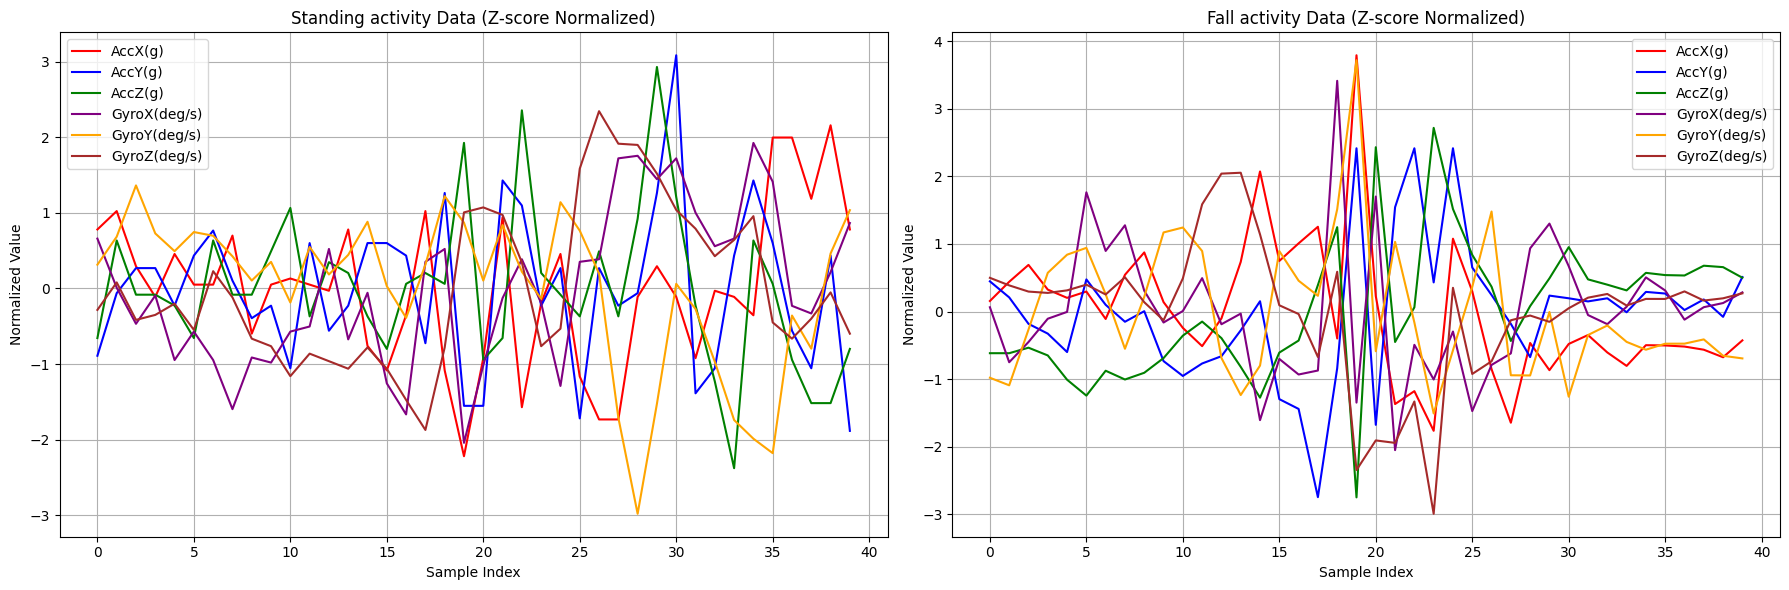

In [ ]:
# Waveform plot for raw data

def z_score_normalize(data):
    """Applies z-score normalization to the input data."""
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    # Handle the case where std is zero to avoid division by zero
    normalized_data = np.where(std == 0, 0, (data - mean) / std)
    return normalized_data


standing_file = None
fall_file = None
for i, label in enumerate(train_labels):
    if label == 1 and standing_file is None: # 1 corresponds to 'standing'
        standing_file = train_files[i]
    if label == 4 and fall_file is None: # 4 corresponds to 'fall'
        fall_file = train_files[i]
    if standing_file is not None and fall_file is not None:
        break


# Process Standing file
df_standing = pd.read_csv(standing_file)
data_standing = df_standing.iloc[:-1, 1:] # Remove last row and timestamp column

scaled_data_standing = z_score_normalize(data_standing)
scaled_data_df_standing = pd.DataFrame(scaled_data_standing, columns=data_standing.columns)

# Process Fall file
df_fall = pd.read_csv(fall_file)
data_fall = df_fall.iloc[:-1, 1:] # Remove last row and timestamp column

scaled_data_fall = z_score_normalize(data_fall)
scaled_data_df_fall = pd.DataFrame(scaled_data_fall, columns=data_fall.columns)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown'] # Define colors for each waveform

# Plot Standing
for i, col in enumerate(scaled_data_df_standing.columns):
    axes[0].plot(scaled_data_df_standing[col], color=colors[i], label=col)
axes[0].set_title('Standing activity Data (Z-score Normalized)')
axes[0].set_xlabel("Sample Index")
axes[0].set_ylabel("Normalized Value")
axes[0].legend()
axes[0].grid(True)

# Plot Fall
for i, col in enumerate(scaled_data_df_fall.columns):
    axes[1].plot(scaled_data_df_fall[col], color=colors[i], label=col)
axes[1].set_title('Fall activity Data (Z-score Normalized)')
axes[1].set_xlabel("Sample Index")
axes[1].set_ylabel("Normalized Value")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

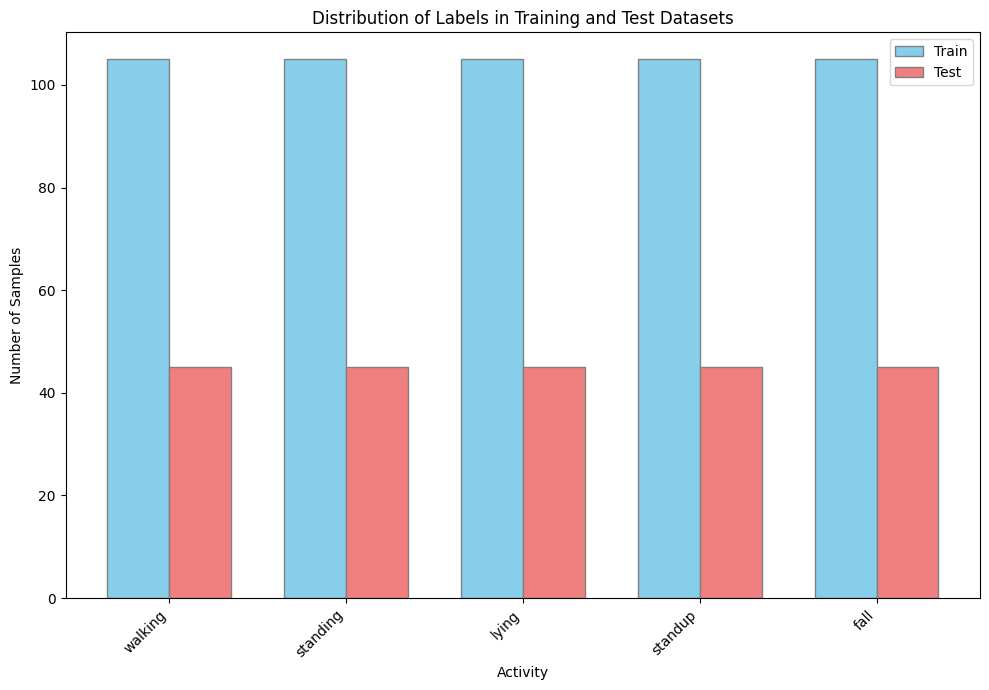

In [ ]:
# Plot label distribution for training and test data in one plot
train_label_counts = pd.Series(train_labels).value_counts().sort_index()
test_label_counts = pd.Series(test_labels).value_counts().sort_index()

# Define a mapping from numerical labels back to activity names for better readability
label_map = {
    0: 'walking',
    1: 'standing',
    2: 'lying',
    3: 'standup',
    4: 'fall'
}
train_label_names = [label_map[i] for i in train_label_counts.index]
test_label_names = [label_map[i] for i in test_label_counts.index]

# Ensure the order of labels is the same for both train and test
all_labels = sorted(list(set(train_label_counts.index) | set(test_label_counts.index)))
all_label_names = [label_map[i] for i in all_labels]

# Create data for plotting
bar_width = 0.35
r1 = np.arange(len(all_labels))
r2 = [x + bar_width for x in r1]

plt.figure(figsize=(10, 7))

# Plotting training data bars
plt.bar(r1, [train_label_counts.get(label, 0) for label in all_labels], color='skyblue', width=bar_width, edgecolor='grey', label='Train')

# Plotting test data bars
plt.bar(r2, [test_label_counts.get(label, 0) for label in all_labels], color='lightcoral', width=bar_width, edgecolor='grey', label='Test')

plt.title('Distribution of Labels in Training and Test Datasets')
plt.xlabel('Activity')
plt.ylabel('Number of Samples')
plt.xticks([r + bar_width/2 for r in range(len(all_labels))], all_label_names, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### Create dataset
class HARDataset: Wrap the dataset into an object (class) to create different instances
- files (list): List of file paths.
- labels (list): List of corresponding labels.
- extract_feature (bool): Extract features or not. Features: min, max, std, mean, skew, kurtosis, median
- feature_set (list): Set of features i.e. [mean, std, skewness, ...] (None if extract_feature is False).
- split (str): 'train' or 'test'.



In [ ]:
class HARDataset(Dataset):
    '''
    Create HARDataset (raw or features) in numpy array format.

    Args:
        files (list): List of file paths.
        labels (list): List of corresponding labels.
        extract_feature (bool): Extract features or not.
        feature_set (list): Set of features i.e. [mean, std, skewness, ...] (None if extract_feature is False).
        split (str): 'train' or 'test'.

    Return:
        tuple: preprocessed data (np.array) and corresponding labels (np.array).
    '''

    def __init__(self, files, labels, extract_feature=False, feature_set=None, split='train'):
        self.files = files
        self.labels = labels
        self.extract_feature = extract_feature
        self.feature_set = feature_set
        self.split = split
        self.data, self.labels = self._load_and_process_data()


    def _load_and_process_data(self):
        '''
        Load and process data.

        Return:
            tuple: preprocessed data (np.array) and corresponding labels (np.array).
        '''
        processed_data = []
        processed_labels = []
        for i, file_path in enumerate(self.files):
            df = pd.read_csv(file_path)

            # Remove last row and timestamp column
            data = df.iloc[:-1, 1:]

            if self.extract_feature:
                features = self._extract_features(data)
                processed_data.append(features)
            else:
                raw_data = self.extract_raw_data(data)
                processed_data.append(raw_data)

            processed_labels.append(self.labels[i])

        processed_data = np.array(processed_data)
        processed_labels = np.array(processed_labels)


        if self.split == 'train':
            # Apply Z-score normalization
            processed_data, self.mean, self.std = self._z_score_normalize(processed_data)
            # Shuffle the data and labels together
            indices = np.arange(processed_data.shape[0])
            np.random.shuffle(indices)
            processed_data = processed_data[indices]
            processed_labels = processed_labels[indices]
        if self.split == 'test':
            # Apply Z-score normalization
            processed_data = self._z_score_normalize(processed_data)

        return processed_data, processed_labels


    def extract_raw_data(self, data):
        '''
        Extract raw data from input data.

        Args:
            data: should be a pandas dataframe (df).

        Return:
            np.array: extracted raw data (for a df).
        '''
        columns_array = [col.values for _, col in data.items()]
        df_array = np.hstack(columns_array)
        return df_array


    def _extract_features(self, data):
        '''
        Extract features from input data.

        Args:
            data: should be a pandas dataframe (df).

        Return:
            np.array: extracted features (np array).
        '''
        features = []
        available_features = {
            'mean': np.mean,
            'std': np.std,
            'min': np.min,
            'max': np.max,
            # 'median': np.median,
            'skew': lambda x: np.mean((x - np.mean(x))**3) / np.std(x)**3,
            'kurtosis': lambda x: np.mean((x - np.mean(x))**4) / np.std(x)**4,
        }

        if self.feature_set is None:
            # If feature_set is not provided, extract all available features
            for feature_name, feature_func in available_features.items():
                features.extend(data.apply(feature_func, axis=0).values)
        else:
            for feature_name in self.feature_set:
                if feature_name in available_features:
                    feature_func = available_features[feature_name]
                    features.extend(data.apply(feature_func, axis=0).values)
                else:
                    print(f"Warning: Feature '{feature_name}' not found in available features.")

        return np.array(features)


    def _z_score_normalize(self, data):
        self.mean = np.mean(data, axis=0)
        self.std = np.std(data, axis=0)
        # Handle the case where std is zero to avoid division by zero
        normalized_data = np.where(self.std == 0, 0, (data - self.mean) / self.std)

        if self.split == 'train':
            return normalized_data, self.mean, self.std
        if self.split == 'test':
            return normalized_data

    def get_normalization_params(self):
        return self.mean, self.std

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

#### Create features dataset

In [ ]:
# Create a features dataset
train_features = HARDataset(train_files, train_labels, extract_feature=True, split='train')
test_features = HARDataset(test_files, test_labels, extract_feature=True, split='test')

# Prepare data
X_train_features = train_features.data
y_train = train_features.labels
X_test_features = test_features.data
y_test = test_features.labels

print("Features dataset shape:", train_features.data.shape)

# Shape should be: (15_file*num_label*num_subject, num_feature*6)

Features dataset shape: (525, 36)


## 2. Visualize features


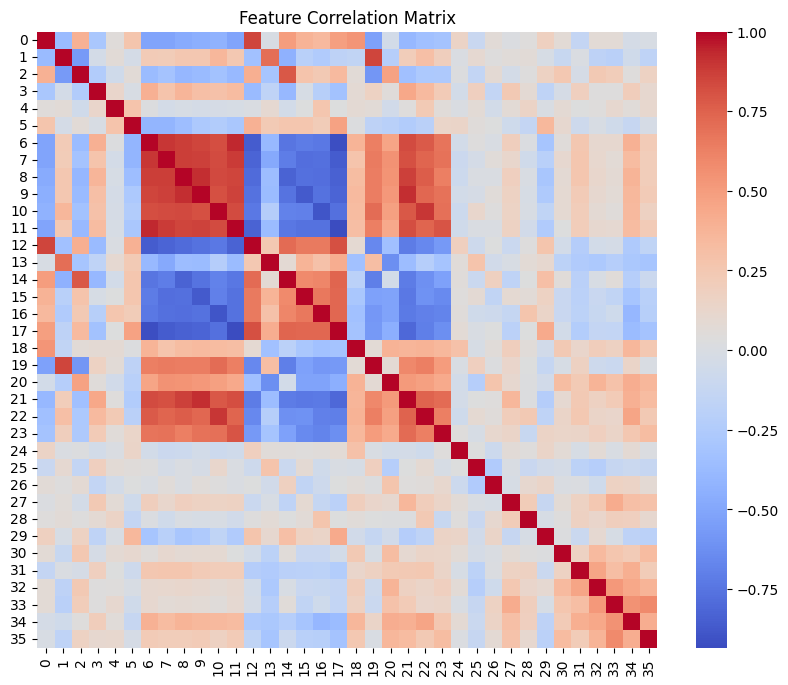


Feature pairs with absolute correlation > 0.9:
Features 9 and 8: 0.9218
Features 11 and 6: 0.9373
Features 17 and 6: -0.9203
Features 17 and 11: -0.9342
Features 21 and 9: 0.9221


In [ ]:
# Calculate and plot the correlation matrix
feature_correlation = pd.DataFrame(X_train_features).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(feature_correlation, annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

# Find and print feature pairs with correlation > 0.9
high_correlation_pairs = {}
for i in range(len(feature_correlation.columns)):
    for j in range(i):
        if abs(feature_correlation.iloc[i, j]) > 0.9:
            colname_i = feature_correlation.columns[i]
            colname_j = feature_correlation.columns[j]
            high_correlation_pairs[(colname_i, colname_j)] = feature_correlation.iloc[i, j]

if high_correlation_pairs:
    print("\nFeature pairs with absolute correlation > 0.9:")
    for pair, correlation in high_correlation_pairs.items():
        print(f"Features {pair[0]} and {pair[1]}: {correlation:.4f}")
else:
    print("\nNo feature pairs with absolute correlation > 0.9 found.")

In [ ]:
# Remove one feature from each highly correlated pair (correlation > 0.9)

# Get the list of columns to drop. For each pair, we drop the second feature.
columns_to_drop = [pair[1] for pair in high_correlation_pairs.keys()]

# Ensure unique columns to drop
columns_to_drop = list(set(columns_to_drop))

# Drop the identified columns from the feature datasets
X_train_features_reduced = pd.DataFrame(X_train_features).drop(columns=columns_to_drop).values
X_test_features_reduced = pd.DataFrame(X_test_features).drop(columns=columns_to_drop).values

print("Original feature dataset shape:", X_train_features.shape)
print("Reduced feature dataset shape:", X_train_features_reduced.shape)

# Update the feature datasets for subsequent steps
X_train_features = X_train_features_reduced
X_test_features = X_test_features_reduced

Original feature dataset shape: (525, 36)
Reduced feature dataset shape: (525, 32)


In [ ]:
X_train_features_df = pd.DataFrame(X_train_features)
X_train_features_df

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,0.349613,0.573346,-0.169617,-0.036362,-0.022081,0.363462,-0.877452,-0.963670,0.650235,0.972468,...,-1.286805,0.034131,-0.883698,1.455091,1.281401,-0.168812,0.379093,-0.262772,0.238439,0.193800
1,-0.449337,0.629332,-0.596956,0.108559,-0.397629,0.172161,-0.070913,0.574750,-0.344219,0.632026,...,-0.571615,0.637176,-0.340983,-0.303309,-0.810135,-0.506029,-0.596531,-0.319193,-0.411985,-0.433092
2,-1.832079,-2.874634,-0.705817,2.848007,-0.510292,-0.436128,0.696850,-0.154082,-1.299702,-2.327465,...,-0.942071,0.200274,-1.692147,-0.420654,-1.148248,-0.589180,-0.047032,0.049033,0.067147,-0.588940
3,-0.296252,0.605411,-0.280222,-0.755006,1.707124,0.458888,0.758707,0.155865,-0.358652,0.515736,...,1.470534,-1.087123,0.943924,0.197769,0.274826,1.100916,0.368130,0.426400,0.074514,-0.073300
4,-0.228171,0.627078,-0.160280,0.111006,2.133752,1.559958,-0.277754,0.715110,0.197029,0.808988,...,-0.180749,-0.507807,-0.947119,0.481504,-0.081231,-0.719344,-0.506414,-0.430687,-0.589501,-0.882914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520,-0.287080,0.604745,0.111411,0.232363,0.256226,0.374733,-0.864118,-0.981973,0.324042,0.979210,...,-0.553282,-0.008783,-0.607852,-1.015255,0.624589,0.280488,0.139180,1.045806,-0.296402,0.674173
521,1.877753,-1.469452,1.225674,-0.171936,-0.039005,0.367023,-0.890027,-1.049895,1.559532,-0.707835,...,1.100852,0.066987,0.313687,0.657638,-1.006919,0.058187,0.191554,-0.445221,-0.681513,-0.299122
522,-0.796460,0.490058,0.013836,0.277991,0.108221,-0.633385,0.347137,0.005902,-0.998047,-0.016838,...,0.637939,-0.114912,-0.520518,-0.945743,-0.696256,0.083264,-0.375097,-0.401842,-0.179103,-0.052336
523,-1.094944,0.445905,-1.113046,2.485354,0.584999,-1.675901,1.227605,2.236598,-1.890024,-0.087623,...,-0.130402,-0.906301,1.682023,-0.811958,0.668958,0.919806,-0.304632,1.355668,0.998938,0.099302


In [ ]:
def scatter_plot(X, y, title, xlabel, ylabel):
    '''
    Generates a scatter plot of the data.

    Args:
        X (np.array): Data to plot (2 components).
        y (np.array): Labels for coloring the points.
        title (str): Title of the plot.
        xlabel (str): Label for the x-axis.
        ylabel (str): Label for the y-axis.
    '''
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10', s=10)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.colorbar(label='Activity Label')
    plt.show()

def plot_confusion_matrix(y_true, y_pred, title):
    '''
    Generates a plot of confusion matrix of the model prediction.

    Args:
        y_true (np.array): True labels.
        y_pred (np.array): Predicted labels.
        title (str): Title of the confusion matrix plot.
    '''
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

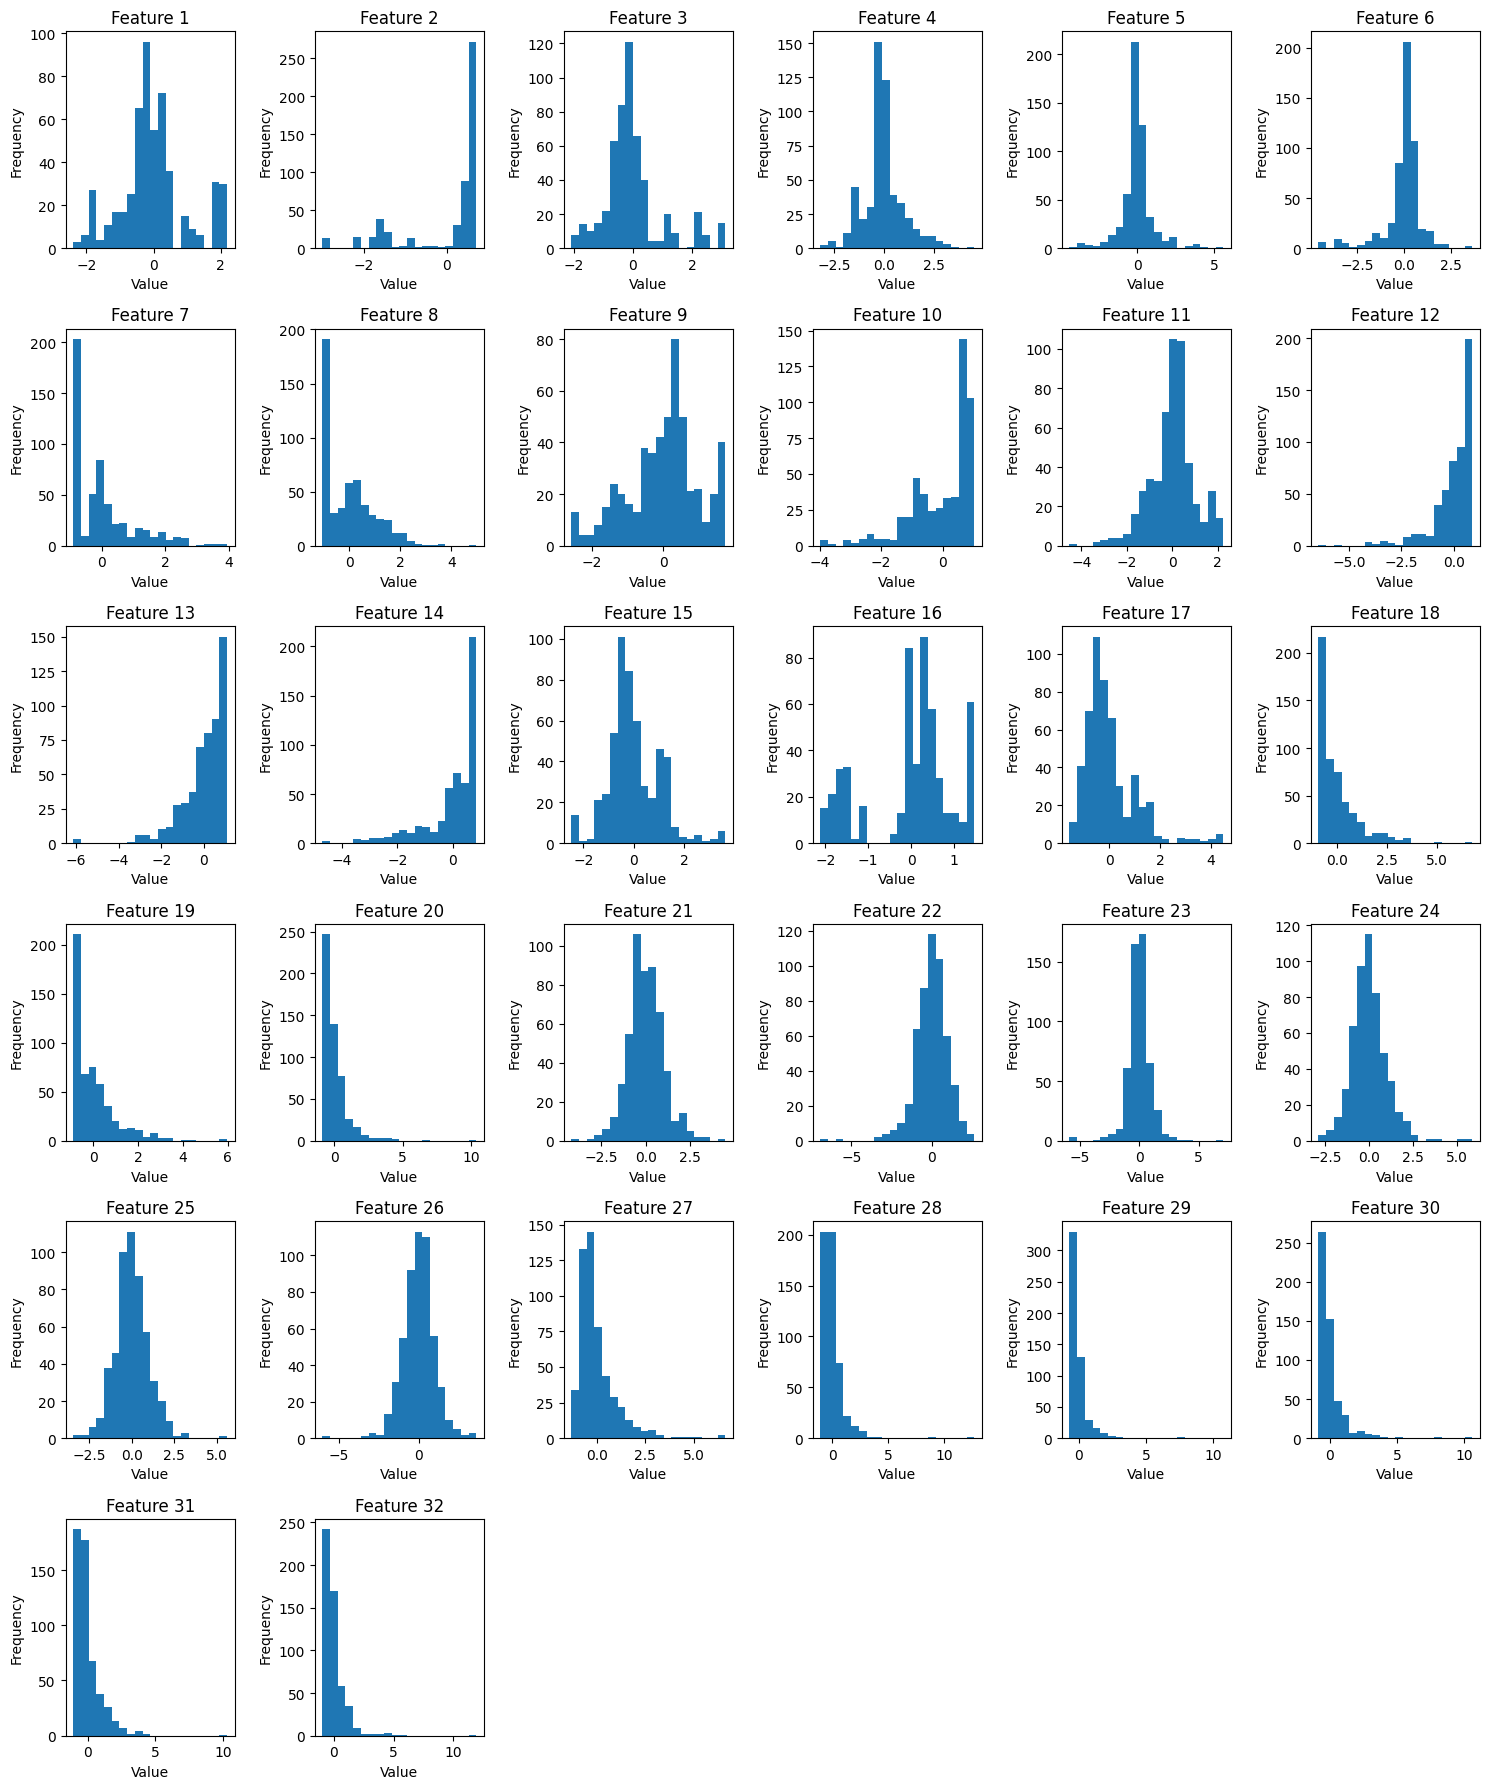

In [ ]:
# Plot histograms for each feature
num_features = X_train_features.shape[1]
num_cols = 6  # Number of columns in the subplot grid
num_rows = (num_features + num_cols - 1) // num_cols # Calculate number of rows needed

plt.figure(figsize=(15, num_rows * 3))

for i in range(num_features):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.hist(X_train_features[:, i], bins=20)
    plt.title(f'Feature {i+1}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

#### Apply PCA and t-SNE for dimensionality reduction features data

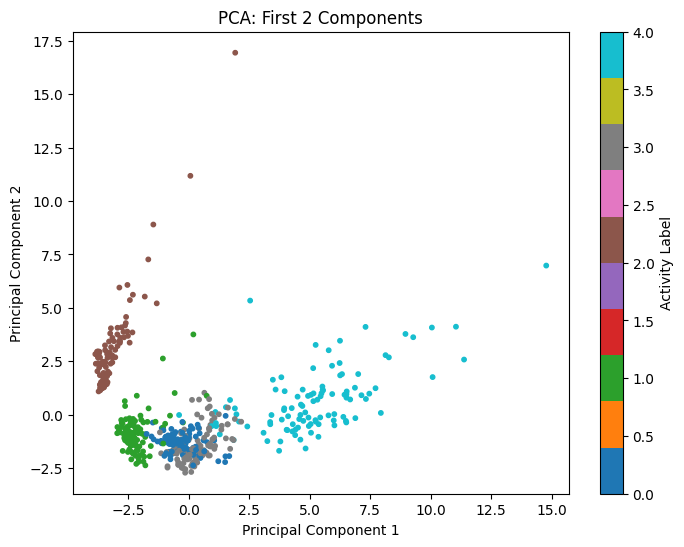

In [ ]:
pca = PCA(n_components=0.99)
X_train_pca = pca.fit_transform(X_train_features)
X_test_pca = pca.transform(X_test_features)

# Scatter plot of the first 2 main components from PCA
scatter_plot(X_train_pca[:, :2], y_train, 'PCA: First 2 Components', 'Principal Component 1', 'Principal Component 2')

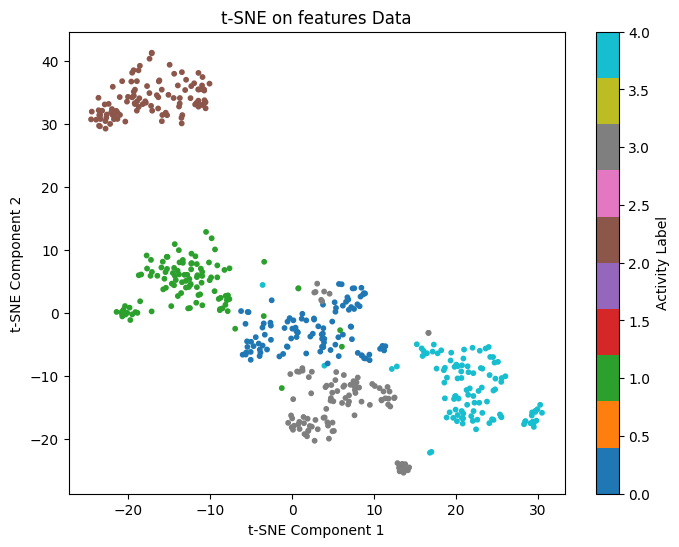

In [ ]:
# t-SNE on PCA-reduced data to 2 components
tsne = TSNE(n_components=2, random_state=42)
X_train_tsne = tsne.fit_transform(X_train_pca)
X_test_tsne = tsne.fit_transform(X_test_pca)

# Scatter plot of t-SNE results
scatter_plot(X_train_tsne, y_train, 't-SNE on features Data', 't-SNE Component 1', 't-SNE Component 2')

## Use Models from sklearn library

### Logistic Regression for activities recognition and for fall detection


--- Logistic Regression from scikit-learn on Features Data with 5-fold Cross-Validation ---

--- 5-fold Cross-Validation Average Results ---
Average Accuracy: 0.9619
Average Precision: 0.9652
Average Recall: 0.9619
Average F1-score: 0.9618
Average AUC (weighted): 0.9969

--- Learned Parameters of the Best Logistic Regression Model (from Cross-Validation) ---
Coefficients (theta):
  Class 0: [ 0.03860053  0.42188774  0.65548023 -0.0708909  -0.02076288  0.08249838
  0.78652141  1.22964463  0.81996884 -0.14701613  0.08801414  0.83897514
 -0.73670539  0.54019855 -0.74573262  0.6611689   0.50578741 -0.68175185
  0.72911706 -0.43926687  0.14381986  1.10353145 -0.24621807 -0.33002859
 -0.29504359  0.03737335  0.09245888 -0.52757189 -0.20099684 -0.04763046
 -0.75372962 -0.35124869]
  Class 1: [-0.26902232  0.54125761 -0.22874287 -0.16332057 -0.04045302 -0.19391086
 -1.55502731 -0.76490163  0.22594959  1.12444845  0.62586692  0.33074673
  0.41626963  0.85233053 -0.93641375 -0.39684122 -0.76650

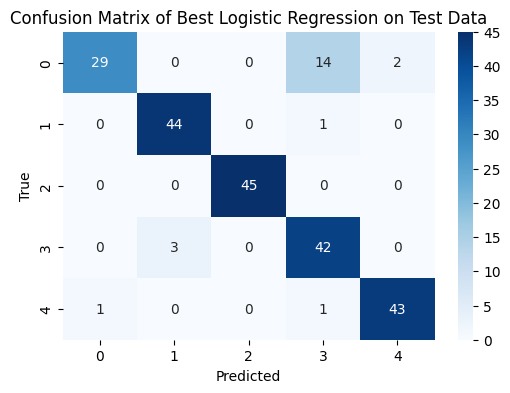

In [ ]:
# --- Logistic Regression from scikit-learn with Cross-Validation and Parameter Extraction ---
print("\n--- Logistic Regression from scikit-learn on Features Data with 5-fold Cross-Validation ---")

kf = KFold(n_splits=5, shuffle=True, random_state=42) # Using 5-fold cross-validation

fold_accuracies = []
fold_precisions = []
fold_recoalls = []
fold_f1_scores = []
fold_auc_scores = []

best_accuracy = 0
best_logistic_reg_model = None
best_params = None

# Initialize LabelBinarizer for AUC calculation
lb = LabelBinarizer()
lb.fit(y_train) # Fit on the training labels to ensure all classes are known

for fold, (train_index, val_index) in enumerate(kf.split(X_train_features, y_train)):
    X_train_fold, X_val_fold = X_train_features[train_index], X_train_features[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    logistic_reg_cv = LogisticRegression(max_iter=1000)
    logistic_reg_cv.fit(X_train_fold, y_train_fold)

    y_pred_cv = logistic_reg_cv.predict(X_val_fold)

    accuracy_cv = accuracy_score(y_val_fold, y_pred_cv)
    precision_cv = precision_score(y_val_fold, y_pred_cv, average='weighted', zero_division=0)
    recall_cv = recall_score(y_val_fold, y_pred_cv, average='weighted', zero_division=0)
    f1_cv = f1_score(y_val_fold, y_pred_cv, average='weighted', zero_division=0)

    # Calculate AUC for the current fold
    y_val_fold_binarized = lb.transform(y_val_fold)
    y_pred_proba_cv = logistic_reg_cv.predict_proba(X_val_fold)

    # Handle missing classes in predict_proba for AUC calculation if necessary
    # This part might need adjustment based on how LabelBinarizer and predict_proba interact with missing classes in folds
    # For simplicity, we assume all classes are present in each validation fold or handle potential errors.
    try:
        auc_cv = roc_auc_score(y_val_fold_binarized, y_pred_proba_cv, average='weighted')
    except ValueError as e:
        print(f"Could not calculate AUC for fold {fold+1}: {e}")
        auc_cv = np.nan # Assign NaN if AUC calculation fails


    fold_accuracies.append(accuracy_cv)
    fold_precisions.append(precision_cv)
    fold_recoalls.append(recall_cv)
    fold_f1_scores.append(f1_cv)
    fold_auc_scores.append(auc_cv)

    # Check if current model is the best based on accuracy
    if accuracy_cv > best_accuracy:
        best_accuracy = accuracy_cv
        best_logistic_reg_model = logistic_reg_cv
        best_params = {
            'coef': logistic_reg_cv.coef_,
            'intercept': logistic_reg_cv.intercept_
        }


print("\n--- 5-fold Cross-Validation Average Results ---")
print(f"Average Accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Average Precision: {np.mean(fold_precisions):.4f}")
print(f"Average Recall: {np.mean(fold_recoalls):.4f}")
print(f"Average F1-score: {np.mean(fold_f1_scores):.4f}")
print(f"Average AUC (weighted): {np.nanmean(fold_auc_scores):.4f}") # Use nanmean to handle potential NaNs in AUC

# Print parameters of the best model
if best_params:
    print("\n--- Learned Parameters of the Best Logistic Regression Model (from Cross-Validation) ---")
    print("Coefficients (theta):")
    for i, coef in enumerate(best_params['coef']):
        print(f"  Class {best_logistic_reg_model.classes_[i]}: {coef}")
    print("Intercept:")
    print(best_params['intercept'])

# Evaluate the best model on the test data
if best_logistic_reg_model:
    print("\n--- Evaluation of the Best Logistic Regression Model on Test Data ---")
    y_pred_lr_test = best_logistic_reg_model.predict(X_test_features)

    accuracy_lr_test = accuracy_score(y_test, y_pred_lr_test)
    precision_lr_test = precision_score(y_test, y_pred_lr_test, average='weighted')
    recall_lr_test = recall_score(y_test, y_pred_lr_test, average='weighted')
    f1_lr_test = f1_score(y_test, y_pred_lr_test, average='weighted')

    print(f"Accuracy: {accuracy_lr_test:.4f}")
    print(f"Precision: {precision_lr_test:.4f}")
    print(f"Recall: {recall_lr_test:.4f}")
    print(f"F1-score: {f1_lr_test:.4f}")

    # AUC for the best model on test data
    y_test_binarized = lb.transform(y_test)
    y_pred_proba_lr_test = best_logistic_reg_model.predict_proba(X_test_features)
    auc_lr_test = roc_auc_score(y_test_binarized, y_pred_proba_lr_test, average='weighted')
    print(f"AUC (weighted): {auc_lr_test:.4f}")

    plot_confusion_matrix(y_test, y_pred_lr_test, "Confusion Matrix of Best Logistic Regression on Test Data")

### SVM


--- SVM from scikit-learn on Features Data with 5-fold Cross-Validation ---
Processing Fold 1...
Processing Fold 2...
Processing Fold 3...
Processing Fold 4...
Processing Fold 5...

--- 5-fold Cross-Validation Average Results ---
Average Accuracy: 0.9486
Average Precision: 0.9511
Average Recall: 0.9486
Average F1-score: 0.9482
Average AUC (weighted): 0.9965

--- Evaluation of the Best SVM Model (Linear Kernel) on Test Data ---
Accuracy: 0.9200
Precision: 0.9293
Recall: 0.9200
F1-score: 0.9196
AUC (weighted): 0.9825


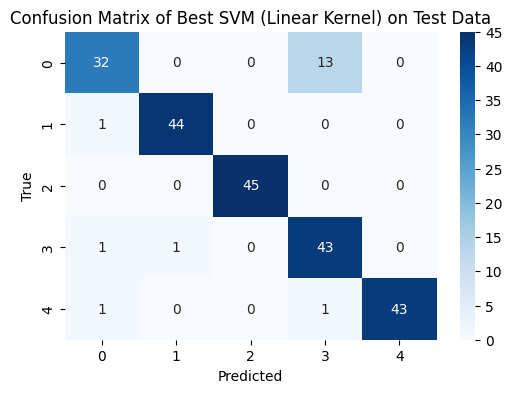

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelBinarizer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- SVM from scikit-learn with Cross-Validation ---
print("\n--- SVM from scikit-learn on Features Data with 5-fold Cross-Validation ---")

kf = KFold(n_splits=5, shuffle=True, random_state=42) # Using 5-fold cross-validation

fold_accuracies = []
fold_precisions = []
fold_recoalls = []
fold_f1_scores = []
fold_auc_scores = []

best_accuracy = 0
best_svm_model = None

# Initialize LabelBinarizer for AUC calculation
lb = LabelBinarizer()
lb.fit(y_train) # Fit on the training labels to ensure all classes are known

for fold, (train_index, val_index) in enumerate(kf.split(X_train_features, y_train)):
    print(f"Processing Fold {fold+1}...")
    X_train_fold, X_val_fold = X_train_features[train_index], X_train_features[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    # Train SVM model (using a linear kernel as a starting point)
    svm_classifier_cv = SVC(kernel='linear', probability=True, random_state=42)
    svm_classifier_cv.fit(X_train_fold, y_train_fold)

    y_pred_cv = svm_classifier_cv.predict(X_val_fold)

    accuracy_cv = accuracy_score(y_val_fold, y_pred_cv)
    precision_cv = precision_score(y_val_fold, y_pred_cv, average='weighted', zero_division=0)
    recall_cv = recall_score(y_val_fold, y_pred_cv, average='weighted', zero_division=0)
    f1_cv = f1_score(y_val_fold, y_pred_cv, average='weighted', zero_division=0)

    # Calculate AUC for the current fold
    y_val_fold_binarized = lb.transform(y_val_fold)
    y_pred_proba_cv = svm_classifier_cv.predict_proba(X_val_fold)

    try:
        auc_cv = roc_auc_score(y_val_fold_binarized, y_pred_proba_cv, average='weighted')
    except ValueError as e:
        print(f"Could not calculate AUC for fold {fold+1}: {e}")
        auc_cv = np.nan # Assign NaN if AUC calculation fails

    fold_accuracies.append(accuracy_cv)
    fold_precisions.append(precision_cv)
    fold_recoalls.append(recall_cv)
    fold_f1_scores.append(f1_cv)
    fold_auc_scores.append(auc_cv)

    # Check if current model is the best based on accuracy
    if accuracy_cv > best_accuracy:
        best_accuracy = accuracy_cv
        best_svm_model = svm_classifier_cv


print("\n--- 5-fold Cross-Validation Average Results ---")
print(f"Average Accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Average Precision: {np.mean(fold_precisions):.4f}")
print(f"Average Recall: {np.mean(fold_recoalls):.4f}")
print(f"Average F1-score: {np.mean(fold_f1_scores):.4f}")
print(f"Average AUC (weighted): {np.nanmean(fold_auc_scores):.4f}") # Use nanmean to handle potential NaNs in AUC


# Evaluate the best model on the test data
if best_svm_model:
    print("\n--- Evaluation of the Best SVM Model (Linear Kernel) on Test Data ---")
    y_pred_svm_test = best_svm_model.predict(X_test_features)

    accuracy_svm_test = accuracy_score(y_test, y_pred_svm_test)
    precision_svm_test = precision_score(y_test, y_pred_svm_test, average='weighted')
    recall_svm_test = recall_score(y_test, y_pred_svm_test, average='weighted')
    f1_svm_test = f1_score(y_test, y_pred_svm_test, average='weighted')

    print(f"Accuracy: {accuracy_svm_test:.4f}")
    print(f"Precision: {precision_svm_test:.4f}")
    print(f"Recall: {recall_svm_test:.4f}")
    print(f"F1-score: {f1_svm_test:.4f}")

    # AUC for the best model on test data (requires probability=True)
    y_test_binarized = lb.transform(y_test)
    y_pred_proba_svm_test = best_svm_model.predict_proba(X_test_features)
    auc_svm_test = roc_auc_score(y_test_binarized, y_pred_proba_svm_test, average='weighted')
    print(f"AUC (weighted): {auc_svm_test:.4f}")

    plot_confusion_matrix(y_test, y_pred_svm_test, "Confusion Matrix of Best SVM (Linear Kernel) on Test Data")

### K-Nearest Neighbors


--- KNN n_neighbors Cross-Validation on Training Set ---
Testing n_neighbors = 1...
Testing n_neighbors = 2...
Testing n_neighbors = 3...
Testing n_neighbors = 4...
Testing n_neighbors = 5...
Testing n_neighbors = 6...
Testing n_neighbors = 7...
Testing n_neighbors = 8...
Testing n_neighbors = 9...
Testing n_neighbors = 10...

--- KNN n_neighbors Cross-Validation Average Results ---
n_neighbors = 1:
  Average Accuracy = 0.9619
  Average Precision = 0.9643
  Average Recall = 0.9619
  Average F1-score = 0.9617
  Average AUC (weighted) = 0.9756
n_neighbors = 2:
  Average Accuracy = 0.9524
  Average Precision = 0.9558
  Average Recall = 0.9524
  Average F1-score = 0.9520
  Average AUC (weighted) = 0.9867
n_neighbors = 3:
  Average Accuracy = 0.9638
  Average Precision = 0.9664
  Average Recall = 0.9638
  Average F1-score = 0.9636
  Average AUC (weighted) = 0.9933
n_neighbors = 4:
  Average Accuracy = 0.9619
  Average Precision = 0.9646
  Average Recall = 0.9619
  Average F1-score = 0.9620

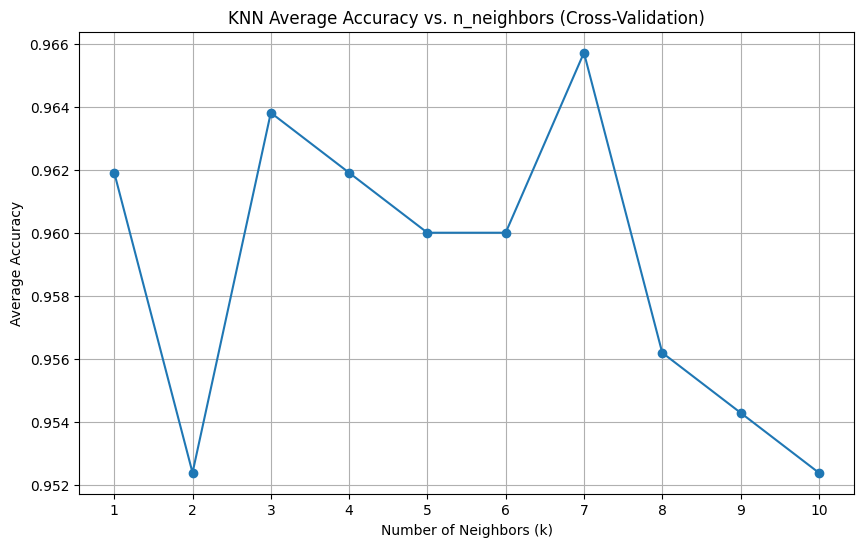

In [ ]:
# Parameter selection for n_neighbors in KNN using cross-validation on the training set
k_range = range(1, 11)
average_accuracies = []
average_precisions = []
average_recoalls = []
average_f1_scores = []
average_auc_scores = []

print("\n--- KNN n_neighbors Cross-Validation on Training Set ---")

# Initialize LabelBinarizer for AUC calculation
lb = LabelBinarizer()
lb.fit(y_train) # Fit on the training labels to ensure all classes are known

for k in k_range:
    print(f"Testing n_neighbors = {k}...")
    kf = KFold(n_splits=5, shuffle=True, random_state=42) # Using 5-fold cross-validation
    accuracies_cv = []
    precisions_cv = []
    recoalls_cv = []
    f1_scores_cv = []
    auc_scores_cv = []

    for fold, (train_index, val_index) in enumerate(kf.split(X_train_features, y_train)):
        X_train_fold, X_val_fold = X_train_features[train_index], X_train_features[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

        knn_cv = KNeighborsClassifier(n_neighbors=k)
        knn_cv.fit(X_train_fold, y_train_fold)

        y_pred_cv = knn_cv.predict(X_val_fold)

        accuracy_cv = accuracy_score(y_val_fold, y_pred_cv)
        precision_cv = precision_score(y_val_fold, y_pred_cv, average='weighted', zero_division=0)
        recall_cv = recall_score(y_val_fold, y_pred_cv, average='weighted', zero_division=0)
        f1_cv = f1_score(y_val_fold, y_pred_cv, average='weighted', zero_division=0)

        # Calculate AUC for the current fold
        y_val_fold_binarized = lb.transform(y_val_fold)
        y_pred_proba_cv = knn_cv.predict_proba(X_val_fold)

        # Handle missing classes in predict_proba for AUC calculation
        missing_cols = len(lb.classes_) - y_pred_proba_cv.shape[1]
        if missing_cols > 0:
            present_classes = knn_cv.classes_
            all_classes = lb.classes_
            missing_classes_indices = [i for i, cls in enumerate(all_classes) if cls not in present_classes]
            zeros_matrix = np.zeros((y_pred_proba_cv.shape[0], missing_cols))
            temp_proba = []
            proba_col_idx = 0
            missing_col_idx = 0
            for i in range(len(all_classes)):
                if all_classes[i] in present_classes:
                    temp_proba.append(y_pred_proba_cv[:, proba_col_idx].reshape(-1, 1))
                    proba_col_idx += 1
                else:
                    temp_proba.append(zeros_matrix[:, missing_col_idx].reshape(-1, 1))
                    missing_col_idx += 1
            y_pred_proba_cv_padded = np.hstack(temp_proba)
        else:
             y_pred_proba_cv_padded = y_pred_proba_cv

        auc_cv = roc_auc_score(y_val_fold_binarized, y_pred_proba_cv_padded, average='weighted')

        accuracies_cv.append(accuracy_cv)
        precisions_cv.append(precision_cv)
        recoalls_cv.append(recall_cv)
        f1_scores_cv.append(f1_cv)
        auc_scores_cv.append(auc_cv)

    # Calculate average scores for the current k
    average_accuracies.append(np.mean(accuracies_cv))
    average_precisions.append(np.mean(precisions_cv))
    average_recoalls.append(np.mean(recoalls_cv))
    average_f1_scores.append(np.mean(f1_scores_cv))
    average_auc_scores.append(np.mean(auc_scores_cv))

# Print average scores for each k
print("\n--- KNN n_neighbors Cross-Validation Average Results ---")
for i, k in enumerate(k_range):
    print(f"n_neighbors = {k}:")
    print(f"  Average Accuracy = {average_accuracies[i]:.4f}")
    print(f"  Average Precision = {average_precisions[i]:.4f}")
    print(f"  Average Recall = {average_recoalls[i]:.4f}")
    print(f"  Average F1-score = {average_f1_scores[i]:.4f}")
    print(f"  Average AUC (weighted) = {average_auc_scores[i]:.4f}")


# Plotting the average accuracies
plt.figure(figsize=(10, 6))
plt.plot(k_range, average_accuracies, marker='o')
plt.title('KNN Average Accuracy vs. n_neighbors (Cross-Validation)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Average Accuracy')
plt.xticks(k_range)
plt.grid(True)
plt.show()

--- KNN from scikit-learn on Full Features Data ---
Accuracy: 0.8667
Precision: 0.8893
Recall: 0.8667
F1-score: 0.8701
AUC (weighted): 0.9753


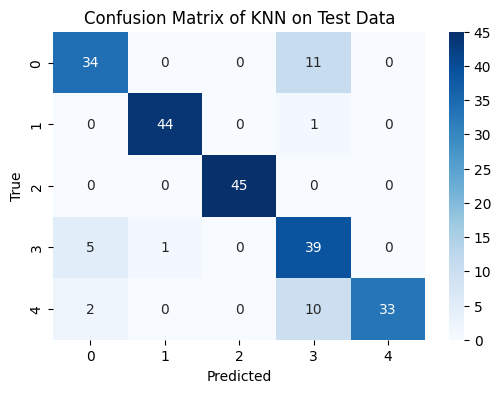

In [ ]:
# --- KNN from scikit-learn ---
print("--- KNN from scikit-learn on Full Features Data ---")
knn = KNeighborsClassifier(n_neighbors=9) # Using k=9 as it is the best model due to k-fold cross validation
knn.fit(X_train_features, y_train)
y_pred_knn = knn.predict(X_test_features)

# Evaluate KNN
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average='weighted')
recall_knn = recall_score(y_test, y_pred_knn, average='weighted')
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')

print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-score: {f1_knn:.4f}")

# AUC is for binary classification, but can be extended to multiclass using one-vs-rest or one-vs-one.
# Using one-vs-rest for multiclass AUC

lb = LabelBinarizer()
lb.fit(y_train)
y_test_binarized = lb.transform(y_test)
y_pred_proba_knn = knn.predict_proba(X_test_features)
auc_knn = roc_auc_score(y_test_binarized, y_pred_proba_knn, average='weighted')
print(f"AUC (weighted): {auc_knn:.4f}")


plot_confusion_matrix(y_test, y_pred_knn, "Confusion Matrix of KNN on Test Data")

### Random Forest


--- Random Forest n_estimators Cross-Validation on Training Set ---
Testing n_estimators = 3...
Testing n_estimators = 5...
Testing n_estimators = 10...
Testing n_estimators = 20...
Testing n_estimators = 50...
Testing n_estimators = 100...
Testing n_estimators = 200...
Testing n_estimators = 250...

--- Random Forest n_estimators Cross-Validation Average Results ---
n_estimators = 3:
  Average Accuracy = 0.8971
  Average Precision = 0.9074
  Average Recall = 0.8971
  Average F1-score = 0.8991
  Average AUC (weighted) = 0.9697
n_estimators = 5:
  Average Accuracy = 0.9371
  Average Precision = 0.9418
  Average Recall = 0.9371
  Average F1-score = 0.9380
  Average AUC (weighted) = 0.9860
n_estimators = 10:
  Average Accuracy = 0.9505
  Average Precision = 0.9528
  Average Recall = 0.9505
  Average F1-score = 0.9506
  Average AUC (weighted) = 0.9932
n_estimators = 20:
  Average Accuracy = 0.9600
  Average Precision = 0.9624
  Average Recall = 0.9600
  Average F1-score = 0.9601
  Average

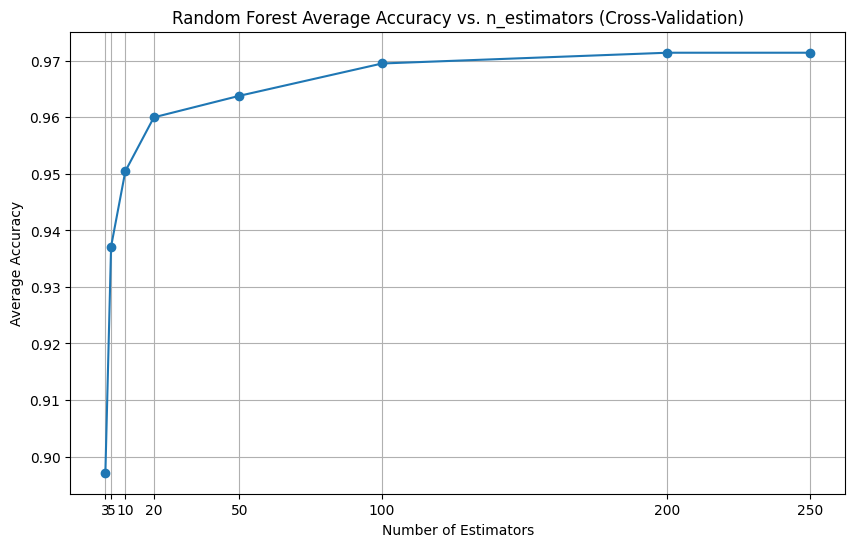

In [ ]:
# Parameter selection for Random Forest (n_estimators) using cross-validation on the training set
n_estimators_range = [3, 5, 10, 20, 50, 100, 200, 250]
average_accuracies = []
average_precisions = []
average_recoalls = []
average_f1_scores = []
average_auc_scores = []

print("\n--- Random Forest n_estimators Cross-Validation on Training Set ---")

# Initialize LabelBinarizer for AUC calculation
lb = LabelBinarizer()
lb.fit(y_train) # Fit on the training labels to ensure all classes are known

for n_estimators in n_estimators_range:
    print(f"Testing n_estimators = {n_estimators}...")
    kf = KFold(n_splits=5, shuffle=True, random_state=42) # Using 5-fold cross-validation
    accuracies_cv = []
    precisions_cv = []
    recoalls_cv = []
    f1_scores_cv = []
    auc_scores_cv = []

    for fold, (train_index, val_index) in enumerate(kf.split(X_train_features, y_train)):
        X_train_fold, X_val_fold = X_train_features[train_index], X_train_features[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

        rf_classifier_cv = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
        rf_classifier_cv.fit(X_train_fold, y_train_fold)

        y_pred_cv = rf_classifier_cv.predict(X_val_fold)

        accuracy_cv = accuracy_score(y_val_fold, y_pred_cv)
        precision_cv = precision_score(y_val_fold, y_pred_cv, average='weighted', zero_division=0)
        recall_cv = recall_score(y_val_fold, y_pred_cv, average='weighted', zero_division=0)
        f1_cv = f1_score(y_val_fold, y_pred_cv, average='weighted', zero_division=0)

        # Calculate AUC for the current fold
        y_val_fold_binarized = lb.transform(y_val_fold)
        y_pred_proba_cv = rf_classifier_cv.predict_proba(X_val_fold)

        # Handle missing classes in predict_proba for AUC calculation
        missing_cols = len(lb.classes_) - y_pred_proba_cv.shape[1]
        if missing_cols > 0:
            present_classes = rf_classifier_cv.classes_
            all_classes = lb.classes_
            missing_classes_indices = [i for i, cls in enumerate(all_classes) if cls not in present_classes]
            zeros_matrix = np.zeros((y_pred_proba_cv.shape[0], missing_cols))
            temp_proba = []
            proba_col_idx = 0
            missing_col_idx = 0
            for i in range(len(all_classes)):
                if all_classes[i] in present_classes:
                    temp_proba.append(y_pred_proba_cv[:, proba_col_idx].reshape(-1, 1))
                    proba_col_idx += 1
                else:
                    temp_proba.append(zeros_matrix[:, missing_col_idx].reshape(-1, 1))
                    missing_col_idx += 1
            y_pred_proba_cv_padded = np.hstack(temp_proba)
        else:
             y_pred_proba_cv_padded = y_pred_proba_cv

        auc_cv = roc_auc_score(y_val_fold_binarized, y_pred_proba_cv_padded, average='weighted')


        accuracies_cv.append(accuracy_cv)
        precisions_cv.append(precision_cv)
        recoalls_cv.append(recall_cv)
        f1_scores_cv.append(f1_cv)
        auc_scores_cv.append(auc_cv)

    # Calculate average scores for the current n_estimators
    average_accuracies.append(np.mean(accuracies_cv))
    average_precisions.append(np.mean(precisions_cv))
    average_recoalls.append(np.mean(recoalls_cv))
    average_f1_scores.append(np.mean(f1_scores_cv))
    average_auc_scores.append(np.mean(auc_scores_cv))


# Print all average results
print("\n--- Random Forest n_estimators Cross-Validation Average Results ---")
for i, n_estimators in enumerate(n_estimators_range):
    print(f"n_estimators = {n_estimators}:")
    print(f"  Average Accuracy = {average_accuracies[i]:.4f}")
    print(f"  Average Precision = {average_precisions[i]:.4f}")
    print(f"  Average Recall = {average_recoalls[i]:.4f}")
    print(f"  Average F1-score = {average_f1_scores[i]:.4f}")
    print(f"  Average AUC (weighted) = {average_auc_scores[i]:.4f}")


# Plotting the average accuracies
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, average_accuracies, marker='o')
plt.title('Random Forest Average Accuracy vs. n_estimators (Cross-Validation)')
plt.xlabel('Number of Estimators')
plt.ylabel('Average Accuracy')
plt.xticks(n_estimators_range)
plt.grid(True)
plt.show()


--- Random Forest from scikit-learn on Features Data ---
Accuracy: 0.8889
Precision: 0.9119
Recall: 0.8889
F1-score: 0.8901
AUC (weighted): 0.9901


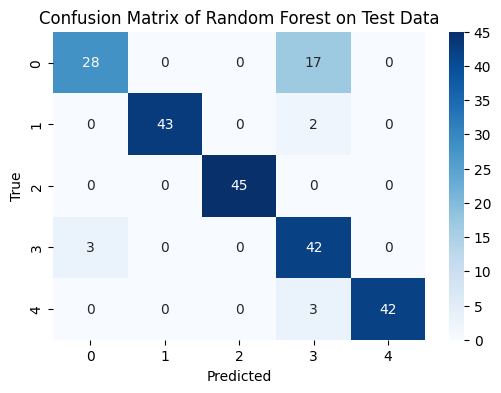

In [ ]:
# --- Random Forest from scikit-learn ---
print("\n--- Random Forest from scikit-learn on Features Data ---")
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42) # Using 100 estimators as it is the best model due to k-fold cross validation
rf_classifier.fit(X_train_features, y_train)
y_pred_rf = rf_classifier.predict(X_test_features)

# Evaluate Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")

# AUC for Random Forest
lb = LabelBinarizer()
lb.fit(y_train)
y_test_binarized = lb.transform(y_test)
y_pred_proba_rf = rf_classifier.predict_proba(X_test_features)
auc_rf = roc_auc_score(y_test_binarized, y_pred_proba_rf, average='weighted')
print(f"AUC (weighted): {auc_rf:.4f}")

plot_confusion_matrix(y_test, y_pred_rf, "Confusion Matrix of Random Forest on Test Data")

### Features Importance

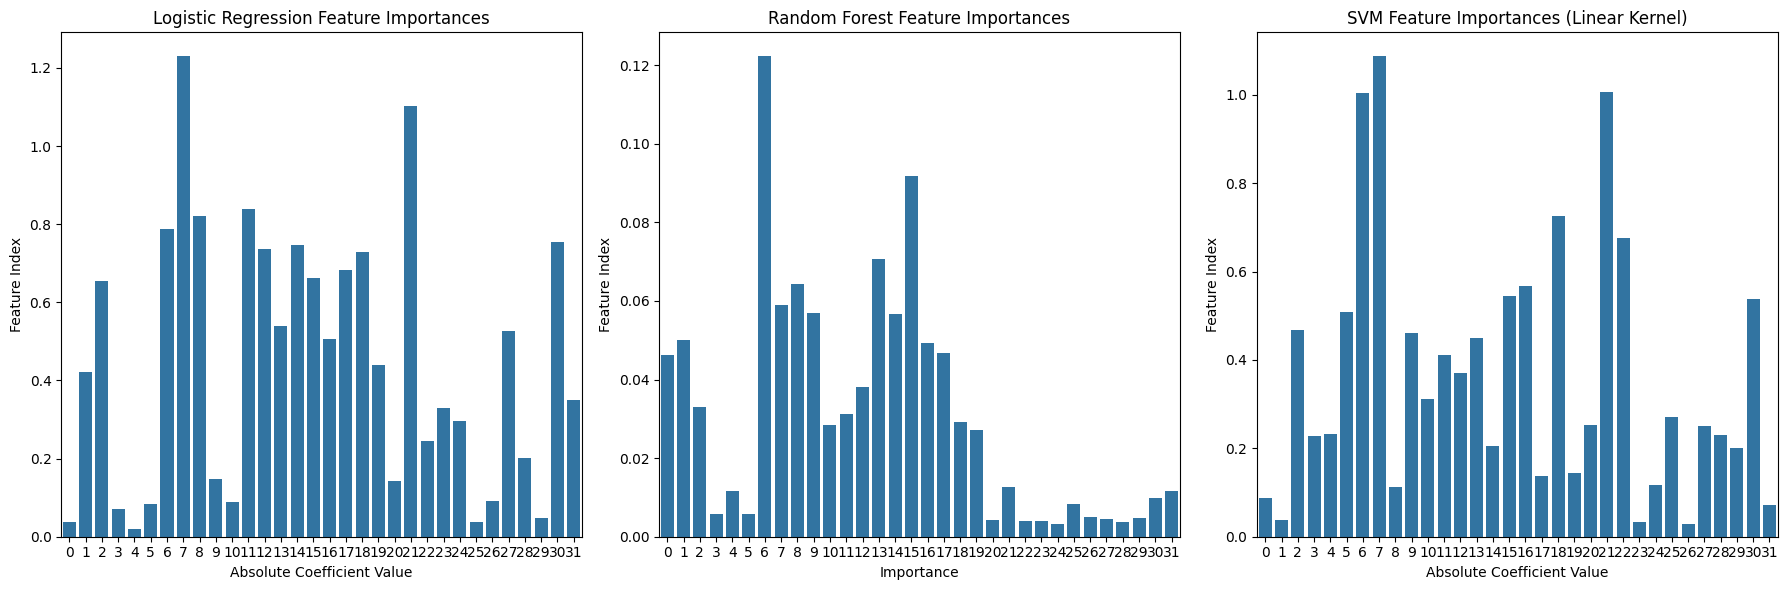


Note: KNN does not provide a direct measure of feature importance in the same way as these models.


In [ ]:
# Plot feature importances for Logistic Regression, Random Forest, and SVM
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Logistic Regression Feature Importances (Absolute Coefficients)
feature_coefficients_lr = best_logistic_reg_model.coef_[0] # Assuming binary or first class for simplicity in visualization
feature_names = pd.DataFrame(X_train_features).columns
feature_importance_lr_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(feature_coefficients_lr)
})
feature_importance_lr_df = feature_importance_lr_df.sort_values(by='Importance', ascending=False)
sns.barplot(x='Feature', y='Importance', data=feature_importance_lr_df, ax=axes[0])
axes[0].set_title('Logistic Regression Feature Importances')
axes[0].set_xlabel('Absolute Coefficient Value')
axes[0].set_ylabel('Feature Index') # Using index as feature names are not available after reduction

# Random Forest Feature Importances
feature_importances_rf = rf_classifier.feature_importances_
feature_importance_rf_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances_rf
})
feature_importance_rf_df = feature_importance_rf_df.sort_values(by='Importance', ascending=False)
sns.barplot(x='Feature', y='Importance', data=feature_importance_rf_df, ax=axes[1])
axes[1].set_title('Random Forest Feature Importances')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('Feature Index')

# SVM Feature Importances (Absolute Coefficients) - for linear kernel
if hasattr(best_svm_model, 'coef_'):
    feature_coefficients_svm = best_svm_model.coef_[0] # Assuming binary or first class for simplicity in visualization
    feature_importance_svm_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': np.abs(feature_coefficients_svm)
    })
    feature_importance_svm_df = feature_importance_svm_df.sort_values(by='Importance', ascending=False)
    sns.barplot(x='Feature', y='Importance', data=feature_importance_svm_df, ax=axes[2])
    axes[2].set_title('SVM Feature Importances (Linear Kernel)')
    axes[2].set_xlabel('Absolute Coefficient Value')
    axes[2].set_ylabel('Feature Index')
else:
    axes[2].set_title('SVM Feature Importances (Not available for non-linear kernel)')
    axes[2].text(0.5, 0.5, 'Feature importances only available\nfor linear kernel', horizontalalignment='center', verticalalignment='center', transform=axes[2].transAxes)


plt.tight_layout()
plt.show()

print("\nNote: KNN does not provide a direct measure of feature importance in the same way as these models.")

# Model extraction and embbeding

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
!pip install m2cgen
from joblib import dump, load
import m2cgen as m2c

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.2/92.2 kB 4.7 MB/s eta 0:00:00


In [ ]:
X_train_features.shape

(525, 32)

In [ ]:
# --- Random Forest from scikit-learn ---
print("\n--- Random Forest from scikit-learn on Features Data ---")
rf_classifier_n8 = RandomForestClassifier(n_estimators=10,max_depth=6,random_state=42) # Using 100 estimators as it is the best model due to k-fold cross validation
rf_classifier_n8.fit(X_train_features, y_train)
y_pred_rf = rf_classifier_n8.predict(X_test_features)

# Evaluate Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")


--- Random Forest from scikit-learn on Features Data ---
Accuracy: 0.9111
Precision: 0.9154
Recall: 0.9111
F1-score: 0.9099


In [ ]:
# --- Logistic Regression from scikit-learn ---
print("\n--- Logistic Regression from scikit-learn on Features Data ---")
logistic_reg_embbed = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=0.5,
    max_iter=500,
    random_state=42
)

logistic_reg_embbed.fit(X_train_features, y_train)


logistic_reg_embbed.fit(X_train_features, y_train)
y_pred_lr = logistic_reg_embbed.predict(X_test_features)

# Evaluate Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average='weighted')
recall_lr = recall_score(y_test, y_pred_lr, average='weighted')
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-score: {f1_lr:.4f}")


--- Logistic Regression from scikit-learn on Features Data ---
Accuracy: 0.9378
Precision: 0.9460
Recall: 0.9378
F1-score: 0.9377


In [ ]:
X_train_features.shape

(525, 32)

In [ ]:
mean_values, std_values = train_features.get_normalization_params()
print("Mean shape:", mean_values.shape)
print("Std shape:", std_values.shape)

# Xuất ra JSON hoặc mảng C
import json
with open("z_params.json", "w") as f:
    json.dump({"mean": mean_values.tolist(), "std": std_values.tolist()}, f, indent=4)


Mean shape: (36,)
Std shape: (36,)


In [ ]:
# Lưu mô hình
dump(rf_classifier_n8, "random_forest_n8.joblib")

# Xuất sang mã C
c_code = m2c.export_to_c(rf_classifier_n8)

# Lưu ra file
with open("rf_model.c", "w") as f:
    f.write(c_code)

print("✅ Model exported to rf_model.c successfully!")


✅ Model exported to rf_model.c successfully!


In [ ]:
# Lưu mô hình
dump(logistic_reg_embbed, "logistic_reg_embbed.joblib")

# Xuất sang mã C
c_code = m2c.export_to_c(logistic_reg_embbed)

# Lưu ra file
with open("logistic_reg_embbed.c", "w") as f:
    f.write(c_code)

print("✅ Model exported to logistic_reg_embbed.c successfully!")

✅ Model exported to logistic_reg_embbed.c successfully!
